# Factor Analysis with Alphalens

**Factor investing** is the idea that you can rank stocks by some measurable characteristic -- a "factor" -- and that stocks with high factor values tend to outperform those with low factor values (or vice versa). Classic factors include:

- **Momentum**: stocks that have gone up tend to keep going up
- **Value**: cheap stocks (relative to fundamentals) tend to outperform
- **Size**: small-cap stocks have historically earned higher returns
- **Quality**: profitable, low-leverage firms tend to outperform

But how do you test whether a factor actually works? That's where [alphalens](https://alphalens.ml4trading.io) comes in. Originally built by [Quantopian](https://en.wikipedia.org/wiki/Quantopian) and now maintained as `alphalens-reloaded`, it provides a structured framework for evaluating alpha factors.

The key question alphalens answers: **does my factor predict future returns?**

## Setup

We'll use `alphalens-reloaded` along with our usual tools. If you need to install it:

```
pip install alphalens-reloaded
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import alphalens
from alphalens.utils import get_clean_factor_and_forward_returns
from alphalens.tears import create_returns_tear_sheet, create_information_tear_sheet, create_turnover_tear_sheet

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## The Data

We need daily prices for a universe of stocks. We'll use 100 large-cap U.S. stocks -- mostly S&P 500 components -- over a six-year period. This gives us enough history to compute trailing 12-month momentum and still have several years of forward returns to analyze.

In [2]:
# 100 large-cap U.S. stocks
tickers = [
    'AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 'META', 'BRK-B', 'UNH', 'JNJ', 'V',
    'XOM', 'JPM', 'PG', 'MA', 'HD', 'CVX', 'MRK', 'ABBV', 'LLY', 'PEP',
    'KO', 'COST', 'AVGO', 'WMT', 'MCD', 'CSCO', 'CRM', 'ACN', 'ABT', 'TMO',
    'LIN', 'DHR', 'CMCSA', 'NKE', 'VZ', 'ADBE', 'TXN', 'NEE', 'PM', 'RTX',
    'BMY', 'UPS', 'HON', 'LOW', 'QCOM', 'UNP', 'SPGI', 'INTC', 'AMGN', 'BA',
    'CAT', 'GS', 'ELV', 'BLK', 'DE', 'ISRG', 'MDLZ', 'GILD', 'SYK', 'ADI',
    'ADP', 'MMC', 'TJX', 'SCHW', 'VRTX', 'PLD', 'REGN', 'CI', 'CB', 'ZTS',
    'SO', 'DUK', 'BDX', 'CME', 'CL', 'MO', 'ITW', 'SLB', 'EOG', 'PNC',
    'AON', 'PYPL', 'WM', 'APD', 'ICE', 'SHW', 'FDX', 'MCK', 'NSC', 'EMR',
    'GD', 'PSX', 'CCI', 'KMB', 'AEP', 'D', 'F', 'GM', 'TROW', 'USB'
]

print(f"Universe: {len(tickers)} stocks")

Universe: 100 stocks


In [3]:
# Load cached prices (or download from yfinance)
import os

DATA_FILE = os.path.join('..', 'data', 'alphalens_prices.csv')

if os.path.exists(DATA_FILE):
    prices = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
    print(f"Loaded cached data: {prices.shape[0]} days, {prices.shape[1]} stocks")
else:
    import yfinance as yf
    data = yf.download(tickers, start='2018-01-01', end='2024-01-01', auto_adjust=True)
    prices = data['Close'].copy()
    threshold = int(len(prices) * 0.9)
    prices = prices.dropna(axis=1, thresh=threshold)
    prices = prices.dropna()
    print(f"Downloaded: {prices.shape[0]} days, {prices.shape[1]} stocks")

prices.head()

[                       0%                       ]

[*                      2%                       ]  2 of 100 completed

[*                      3%                       ]  3 of 100 completed

[**                     5%                       ]  5 of 100 completed

[***                    6%                       ]  6 of 100 completed

...

[**********************98%********************** ]  98 of 100 completed

[**********************99%***********************]  99 of 100 completed

[*********************100%***********************]  100 of 100 completed

Downloaded: 1509 days, 100 stocks


Ticker,AAPL,ABBV,ABT,ACN,ADBE,ADI,ADP,AEP,AMGN,AMZN,...,UNP,UPS,USB,V,VRTX,VZ,WM,WMT,XOM,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.304173,69.343704,50.822945,136.707855,177.699997,77.602280,97.942856,54.101398,137.775192,59.450500,...,113.271835,89.841103,39.419220,108.111916,152.910004,34.220024,75.054329,28.914413,58.580429,67.104774
2018-01-03,40.297150,70.428848,50.935318,137.338776,181.039993,78.565010,99.006813,53.645626,140.375000,60.209999,...,113.905846,91.831604,39.805893,109.188225,152.009995,33.516827,76.143997,29.166641,59.730961,67.413330
2018-01-04,40.484337,70.027206,50.848858,138.964966,183.220001,78.479065,99.952560,53.010544,139.783401,60.479500,...,113.288536,92.427307,40.112331,109.594177,153.070007,33.625500,76.797760,29.193029,59.813599,67.815392
2018-01-05,40.945255,71.246223,50.995827,140.111313,185.339996,78.797112,99.893456,52.898476,140.616287,61.457001,...,114.731743,92.710609,40.360359,112.218872,155.690002,33.548782,76.701889,29.366062,59.765411,68.591415
2018-01-08,40.793186,70.104698,50.848858,141.231018,185.039993,78.934631,99.589470,53.361702,140.577393,62.343498,...,116.325142,93.836639,40.418739,112.672005,156.889999,33.491257,76.754196,29.800119,60.034061,69.414207


## Building a Momentum Factor

We'll construct the classic **12-1 momentum factor** from [Jegadeesh and Titman (1993)](https://doi.org/10.1111/j.1540-6261.1993.tb04702.x). The idea:

- Look at each stock's return over the **past 12 months**
- **Skip the most recent month** (this avoids short-term reversal effects)
- Rank stocks by this trailing return
- Go **long** the top quartile (25 stocks) and **short** the bottom quartile (25 stocks)

Why skip the most recent month? There's a well-documented [short-term reversal effect](https://en.wikipedia.org/wiki/Contrarian_investing) -- stocks that went up last month tend to fall back a bit, and vice versa. The 12-1 momentum factor isolates the medium-term trend.

In [4]:
# Step 1: Get month-end prices
monthly_prices = prices.resample('ME').last()
print(f"Monthly prices: {monthly_prices.shape[0]} months, {monthly_prices.shape[1]} stocks")

# Step 2: Compute 12-1 momentum
# shift(1) skips the most recent month
# pct_change(11) gives the return over the prior 11 months
# Together: return from t-12 to t-1
momentum = monthly_prices.shift(1).pct_change(11)
momentum = momentum.dropna(how='all')

print(f"Momentum signals: {momentum.shape[0]} months")
momentum.tail()

Monthly prices: 72 months, 100 stocks
Momentum signals: 60 months


Ticker,AAPL,ABBV,ABT,ACN,ADBE,ADI,ADP,AEP,AMGN,AMZN,...,UNP,UPS,USB,V,VRTX,VZ,WM,WMT,XOM,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2023-08-31,0.255240,0.157581,0.105357,0.114442,0.462537,0.335151,0.032701,-0.130609,-0.000890,0.054508,...,0.053927,-0.010977,-0.084409,0.203731,0.250497,-0.128863,-0.014737,0.220161,0.149497,0.212258
2023-09-30,0.367471,0.139423,0.083849,0.278710,1.032485,0.322790,0.144113,-0.058049,0.175546,0.221327,...,0.161363,0.087818,-0.057553,0.394074,0.203081,-0.015431,-0.008707,0.272933,0.315561,0.296083
2023-10-31,0.123162,0.048803,-0.007038,0.094402,0.600942,0.250723,0.016758,-0.111366,0.027580,0.240922,...,0.059551,-0.036235,-0.177737,0.119237,0.114551,-0.088483,-0.020554,0.140859,0.096134,0.161611
2023-11-30,0.158539,-0.088700,-0.103537,0.002925,0.542516,-0.067625,-0.156092,-0.196989,-0.083455,0.378599,...,-0.020546,-0.234876,-0.258444,0.089694,0.144469,-0.032574,-0.003020,0.088516,-0.025759,0.027846
2023-12-31,0.470113,-0.083335,-0.031093,0.268299,0.815618,0.133913,-0.021482,-0.128067,0.062236,0.739167,...,0.109108,-0.093195,-0.087323,0.245275,0.228652,0.044297,0.109343,0.110655,-0.036739,0.216524


Each value in the table above is the trailing 12-1 month return for that stock. For example, a value of 0.30 means the stock went up 30% over the past year (excluding the most recent month). A value of -0.15 means it fell 15%.

The momentum strategy says: **buy the winners and sell the losers**.

## Preparing Data for Alphalens

Alphalens expects the factor data in a specific format: a pandas **Series** with a **MultiIndex** of `(date, asset)`. Each entry is the factor value for that stock on that date.

We also need to make sure our factor dates are actual trading days (days that appear in our daily price data), since alphalens uses the daily prices to compute forward returns.

In [5]:
# Get the last trading day of each month from our price data
month_end_trading = prices.resample('ME').last().index

# Forward-fill momentum to daily dates, then keep only month-end trading days
momentum_daily = momentum.reindex(prices.index, method='ffill')
momentum_filtered = momentum_daily.loc[momentum_daily.index.isin(month_end_trading)]

# Stack into the MultiIndex format alphalens expects
factor = momentum_filtered.stack()
factor.index.names = ['date', 'asset']
factor = factor.dropna()
factor.name = 'momentum'

print(f"Factor observations: {len(factor):,}")
print(f"Unique dates: {factor.index.get_level_values('date').nunique()}")
print(f"Unique assets: {factor.index.get_level_values('asset').nunique()}")

Factor observations: 4,200
Unique dates: 42
Unique assets: 100


In [6]:
# Look at the factor for one date
sample_date = factor.index.get_level_values('date').unique()[12]
sample = factor.loc[sample_date].sort_values()

print(f"Factor values on {sample_date.strftime('%Y-%m-%d')}:")
print(f"  Bottom 5 (short candidates): ")
print(sample.head().to_string())
print(f"\n  Top 5 (long candidates):")
print(sample.tail().to_string())

Factor values on 2020-07-31:
  Bottom 5 (short candidates): 
asset
SLB   -0.515902
BA    -0.453004
EOG   -0.400136
XOM   -0.362814
GM    -0.351929

  Top 5 (long candidates):
asset
PYPL    0.578170
AAPL    0.732790
VRTX    0.742348
REGN    1.046364
NVDA    1.257990


## Running Alphalens

The core function is `get_clean_factor_and_forward_returns()`. It takes our factor and pricing data and:

1. Computes **forward returns** at specified horizons (we'll use 5, 10, and 21 trading days -- roughly 1 week, 2 weeks, and 1 month)
2. Sorts stocks into **quantiles** based on the factor value (we'll use 4 quantiles, so Q1 is the bottom 25% and Q4 is the top 25%)
3. Aligns everything into a clean DataFrame

In [7]:
factor_data = get_clean_factor_and_forward_returns(
    factor,
    prices,
    quantiles=4,
    periods=(5, 10, 21)
)

factor_data.head(10)

Dropped 2.4% entries from factor data: 2.4% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


5D       10D       21D    factor  factor_quantile
date       asset                                                         
2019-01-31 AAPL   0.027036  0.030597  0.061068 -0.043731                3
           ABBV  -0.013950  0.002864 -0.010337 -0.152533                2
           ABT   -0.003289  0.013565  0.077281  0.179295                4
           ACN    0.010615  0.028004  0.060371 -0.106692                2
           ADBE   0.023888  0.049714  0.041724  0.132559                4
           ADI    0.017904  0.056950  0.104762 -0.046901                3
           ADP    0.041762  0.059425  0.095967  0.083032                4
           AEP    0.012737  0.011463  0.037849  0.127236                4
           AMGN  -0.015392  0.005417  0.022112  0.077078                4
           AMZN  -0.060719 -0.055902 -0.013126  0.035206                3

Each row is a `(date, asset)` observation. The columns are:

- **5D, 10D, 21D**: Forward returns at each horizon (what the stock actually returned *after* the signal)
- **factor**: The momentum score
- **factor_quantile**: Which quartile (1 = lowest momentum, 4 = highest momentum)

If momentum works, we'd expect Q4 stocks (winners) to have higher forward returns than Q1 stocks (losers).

## Returns Analysis

The returns tear sheet shows us the average return by quantile. This is the most important output -- it tells us whether the factor actually predicts returns.

Returns Analysis


,5D,10D,21D
Ann. alpha,-0.007,0.031,0.050
beta,-0.109,-0.104,-0.114
Mean Period Wise Return Top Quantile (bps),-5.661,0.060,3.809
Mean Period Wise Return Bottom Quantile (bps),1.837,0.012,-8.039
Mean Period Wise Spread (bps),-7.498,0.150,11.995


<Figure size 640x480 with 0 Axes>

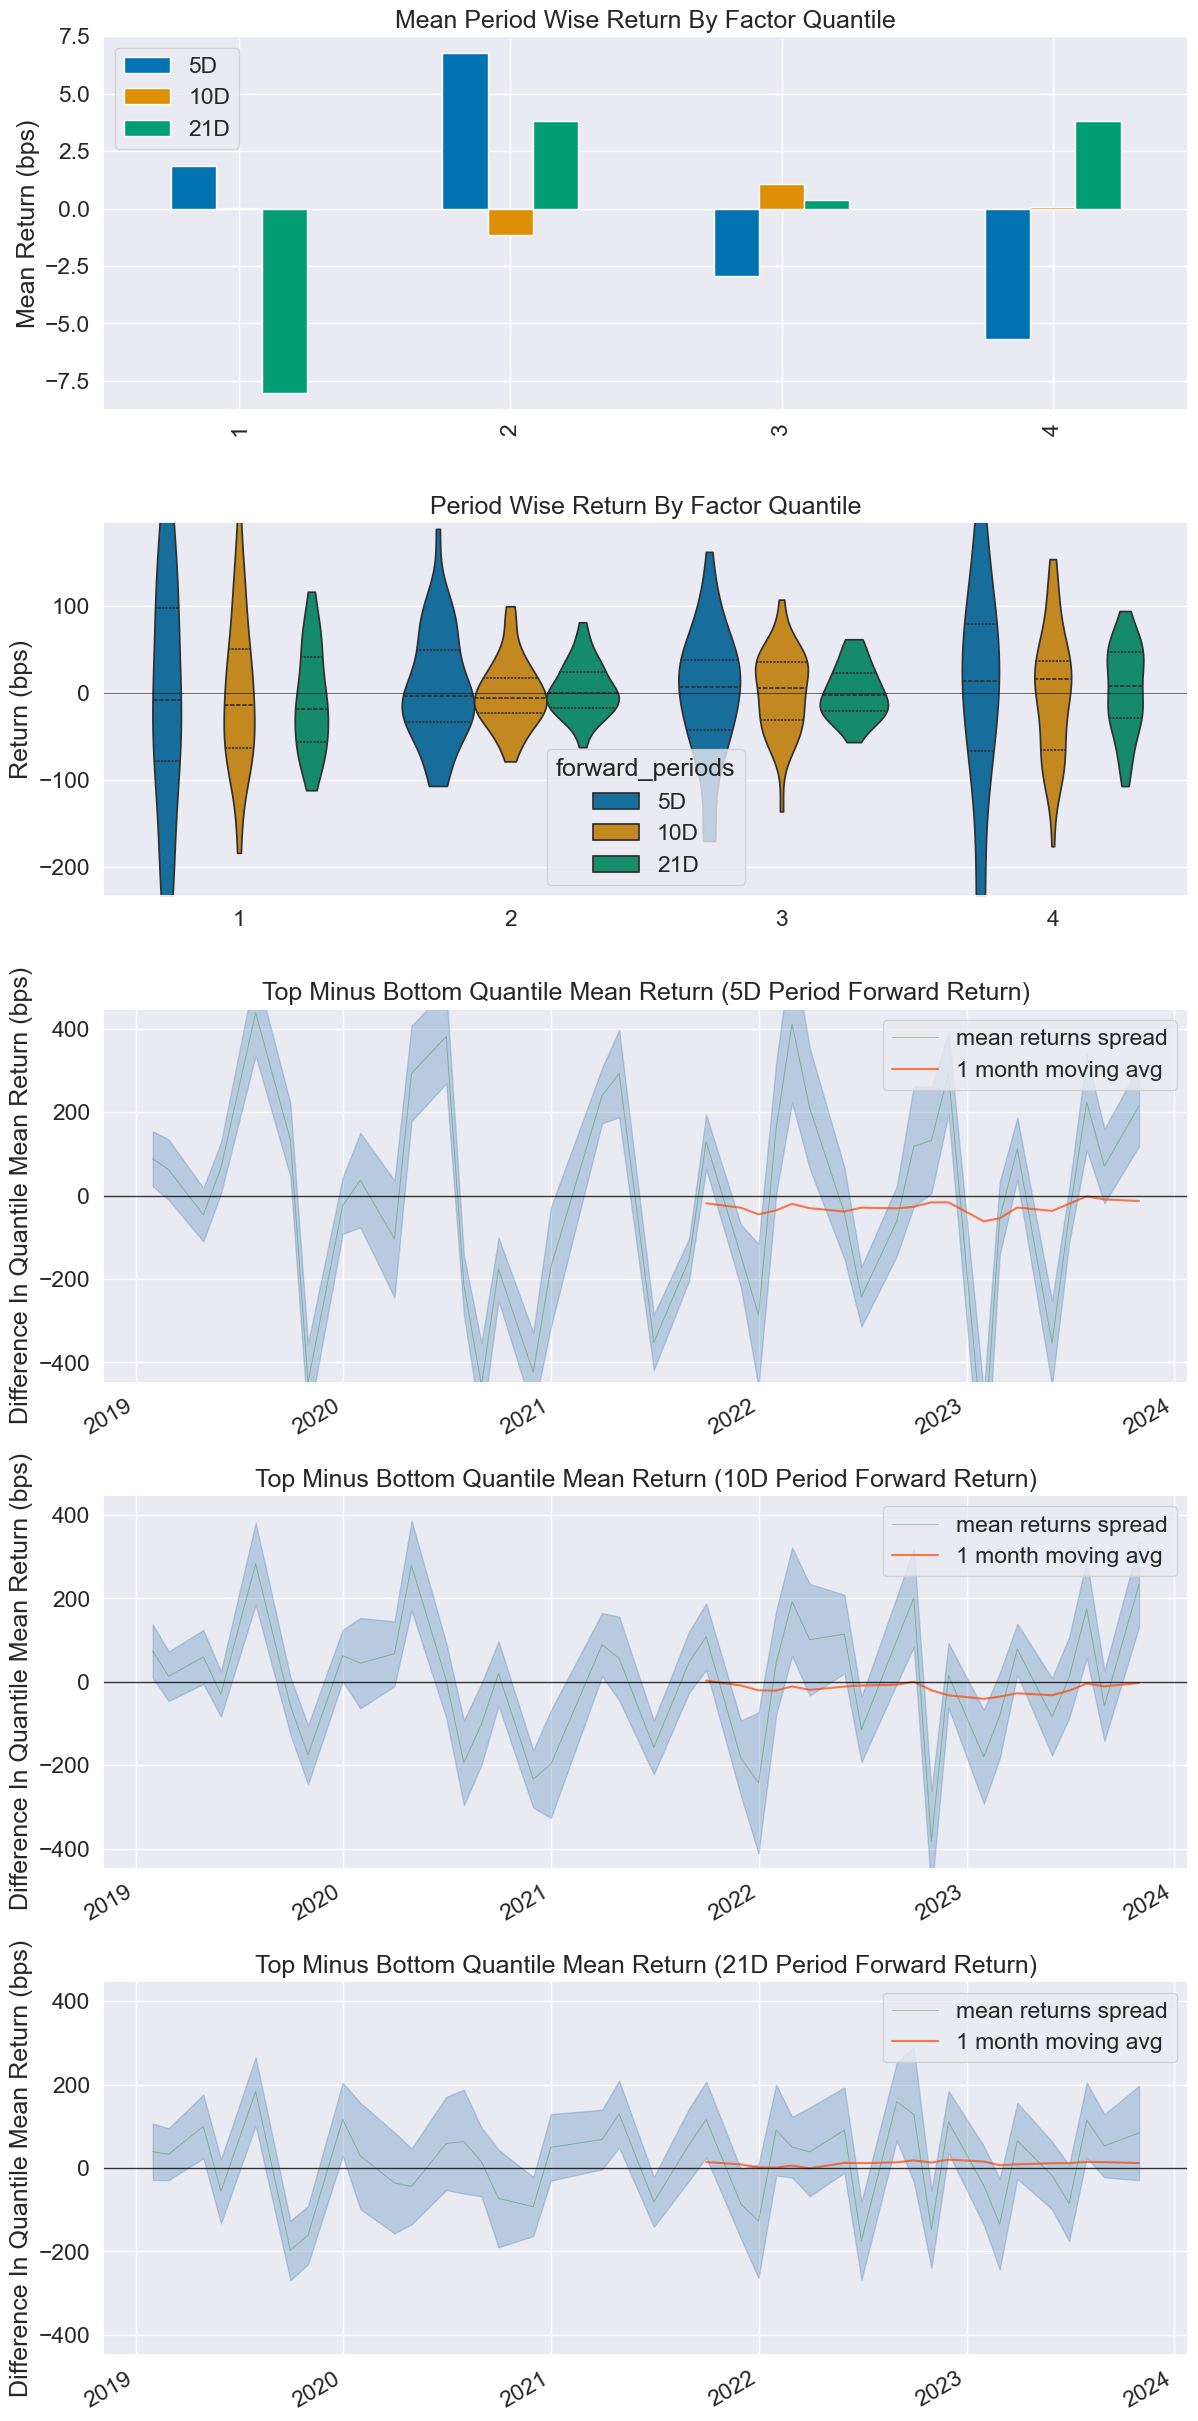

In [8]:
create_returns_tear_sheet(factor_data)

### Reading the Output

Look at the **Mean Period Wise Return by Factor Quantile** chart. A good momentum factor shows a clear staircase pattern: Q1 (bottom) has the lowest returns and Q4 (top) has the highest.

The **Returns Analysis** table at the top shows:
- **Mean Period Wise Return Top Quantile (bps)**: Average return of the top quartile in basis points
- **Mean Period Wise Return Bottom Quantile (bps)**: Average return of the bottom quartile
- **Mean Period Wise Spread (bps)**: The difference (long top, short bottom) -- this is your strategy's return

A positive spread at the 21D horizon means that momentum had some predictive power over a monthly horizon in this sample.

## Information Coefficient (IC)

The **Information Coefficient** measures the rank correlation (Spearman) between the factor value and forward returns. An IC of 0.05 might sound small, but in practice, even IC values between 0.02 and 0.05 can be economically meaningful -- you're trying to find a small, persistent edge across many stocks.

Information Analysis


,5D,10D,21D
IC Mean,-0.013,0.003,0.029
IC Std.,0.275,0.238,0.248
Risk-Adjusted IC,-0.047,0.012,0.118
t-stat(IC),NaN,NaN,NaN
p-value(IC),NaN,NaN,NaN
IC Skew,NaN,NaN,NaN
IC Kurtosis,NaN,NaN,NaN


<Figure size 640x480 with 0 Axes>

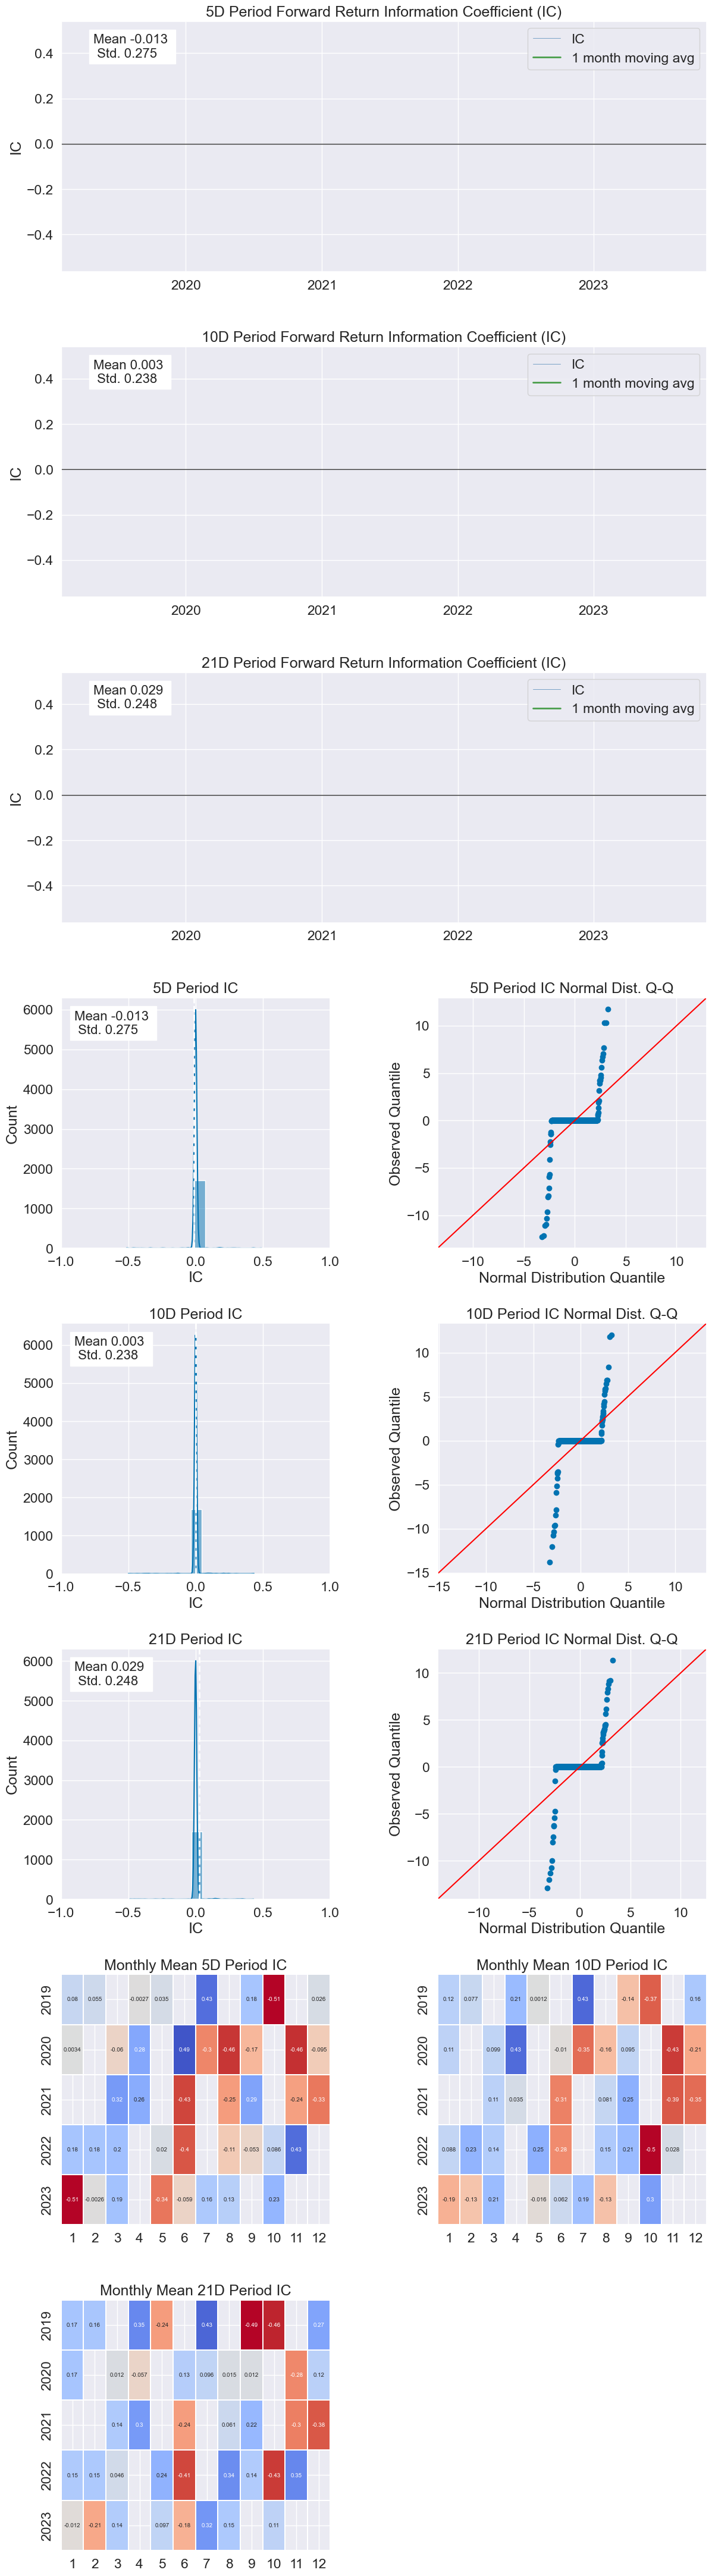

In [9]:
create_information_tear_sheet(factor_data)

The **IC heatmap** shows whether the factor's predictive power is consistent over time or concentrated in certain periods. The **IC histogram** shows the distribution of monthly IC values -- ideally, most values should be positive (for a long-momentum factor).

Note that we only have a limited sample here. Professional quant researchers would use much longer histories and more sophisticated factor construction.

## Turnover Analysis

**Turnover** measures how much the portfolio changes each period. High turnover means you're trading a lot, which means high transaction costs. A factor can look great before costs but be unprofitable after accounting for trading.

In [10]:
create_turnover_tear_sheet(factor_data)

Turnover Analysis


,5D,10D,21D
Quantile 1 Mean Turnover,NaN,NaN,NaN
Quantile 2 Mean Turnover,NaN,NaN,NaN
Quantile 3 Mean Turnover,NaN,NaN,NaN
Quantile 4 Mean Turnover,NaN,NaN,NaN


,5D,10D,21D
Mean Factor Rank Autocorrelation,NaN,NaN,NaN


<Figure size 640x480 with 0 Axes>

<Figure size 1400x12600 with 0 Axes>

## Building the Long-Short Portfolio

Now let's see what a practical long-short momentum strategy looks like. Each month, we:
1. Rank all 100 stocks by 12-1 momentum
2. Go **long** the top 25 (Q4)
3. Go **short** the bottom 25 (Q1)
4. Equal-weight within each leg

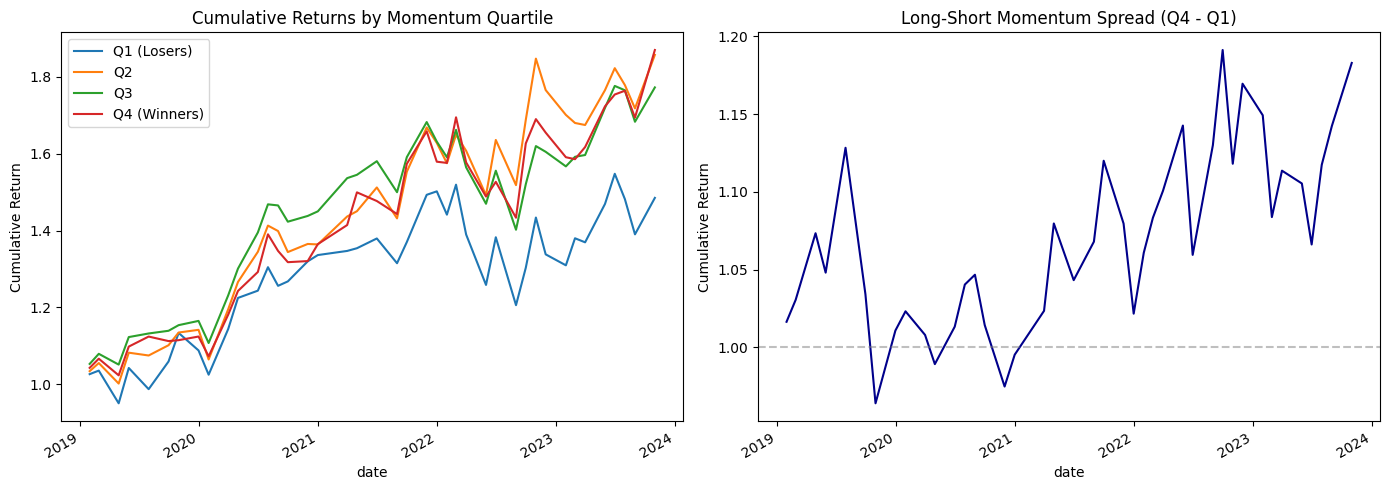

In [11]:
# Compute monthly returns for each quantile
quantile_returns = factor_data.groupby(
    [factor_data.index.get_level_values('date'), 'factor_quantile']
)['21D'].mean().unstack('factor_quantile')

# Long-short spread: Q4 - Q1
quantile_returns['Long-Short'] = quantile_returns[4] - quantile_returns[1]

# Cumulative returns
cumulative = (1 + quantile_returns).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot cumulative returns by quantile
cumulative[[1, 2, 3, 4]].plot(ax=axes[0])
axes[0].set_title('Cumulative Returns by Momentum Quartile')
axes[0].set_ylabel('Cumulative Return')
axes[0].legend(['Q1 (Losers)', 'Q2', 'Q3', 'Q4 (Winners)'])

# Plot long-short spread
cumulative['Long-Short'].plot(ax=axes[1], color='darkblue')
axes[1].set_title('Long-Short Momentum Spread (Q4 - Q1)')
axes[1].set_ylabel('Cumulative Return')
axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout();

## Does Momentum Work?

The results above are mixed -- and that's the point. A few things to consider:

1. **Sample period matters**: Momentum tends to work well during trending markets but suffers sharp reversals during market crashes and recoveries ("momentum crashes"). Our sample includes COVID-19, which created a massive momentum reversal.

2. **Transaction costs**: We haven't accounted for the cost of trading 50 stocks each month. Momentum strategies have relatively high turnover, which eats into returns.

3. **Survivorship bias**: Our universe only includes stocks that are large today. Some of the best momentum stocks from 2018 might have been smaller then, and some 2018 large-caps may have declined and left the index. This biases our results.

4. **Data snooping**: We picked momentum because we *know* it's a famous factor. If we'd tested hundreds of potential factors and only reported the best one, we'd be fooling ourselves. This is the **multiple testing problem**.

5. **Capacity**: Even if momentum works, can you trade it at scale? The biggest gains often come from the smallest, least liquid stocks.

## What Quants Actually Do

In practice, quantitative investment firms like AQR, Two Sigma, or Citadel don't rely on a single factor. They:

- Test **hundreds of potential factors** using tools like alphalens
- Combine factors into **composite signals** (e.g., momentum + value + quality)
- Use **sophisticated risk models** to control exposure to market risk, sectors, and other sources of unintended bets
- Optimize **portfolio construction** to maximize expected return per unit of risk while minimizing turnover

Alphalens is the first step in this pipeline -- it tells you whether a factor is worth investigating further. The full pipeline requires portfolio optimization (see [Chapter 9](../chapters/9_portfolio_opt)), risk management (see [Chapter 14](../chapters/14_risk_mang)), and a backtesting framework (see the [BT chapter](../chapters/18_0_trading_bt)).

```{tip}
Try modifying the factor. Instead of 12-1 momentum, what if you used 6-month momentum? 3-month? What about a **reversal** factor (short recent winners, long recent losers)? Alphalens makes it easy to test these variations.
```